In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('/Users/devammpatel/Desktop/Consumer_Shopping_Trend/Dataset/Consumer_Shopping_Trends_2026_updated.csv')
df.head()

,age,monthly_income,monthly_online_orders,monthly_store_visits,avg_online_spend,avg_store_spend,product_availability_online,gender_encoded,city_tier_encoded,shopping_preference_encoded
0,56,221111,16,16,28551,144092,7,2,2,2
1,69,96029,14,1,124056,28421,4,1,2,0
2,46,19055,2,0,81939,128229,10,0,2,2
3,32,53170,20,3,35901,134650,2,0,0,2
4,60,244016,18,16,131971,34122,5,1,2,2


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   age                          11789 non-null  int64
 1   monthly_income               11789 non-null  int64
 2   monthly_online_orders        11789 non-null  int64
 3   monthly_store_visits         11789 non-null  int64
 4   avg_online_spend             11789 non-null  int64
 5   avg_store_spend              11789 non-null  int64
 6   product_availability_online  11789 non-null  int64
 7   gender_encoded               11789 non-null  int64
 8   city_tier_encoded            11789 non-null  int64
 9   shopping_preference_encoded  11789 non-null  int64
dtypes: int64(10)
memory usage: 921.1 KB


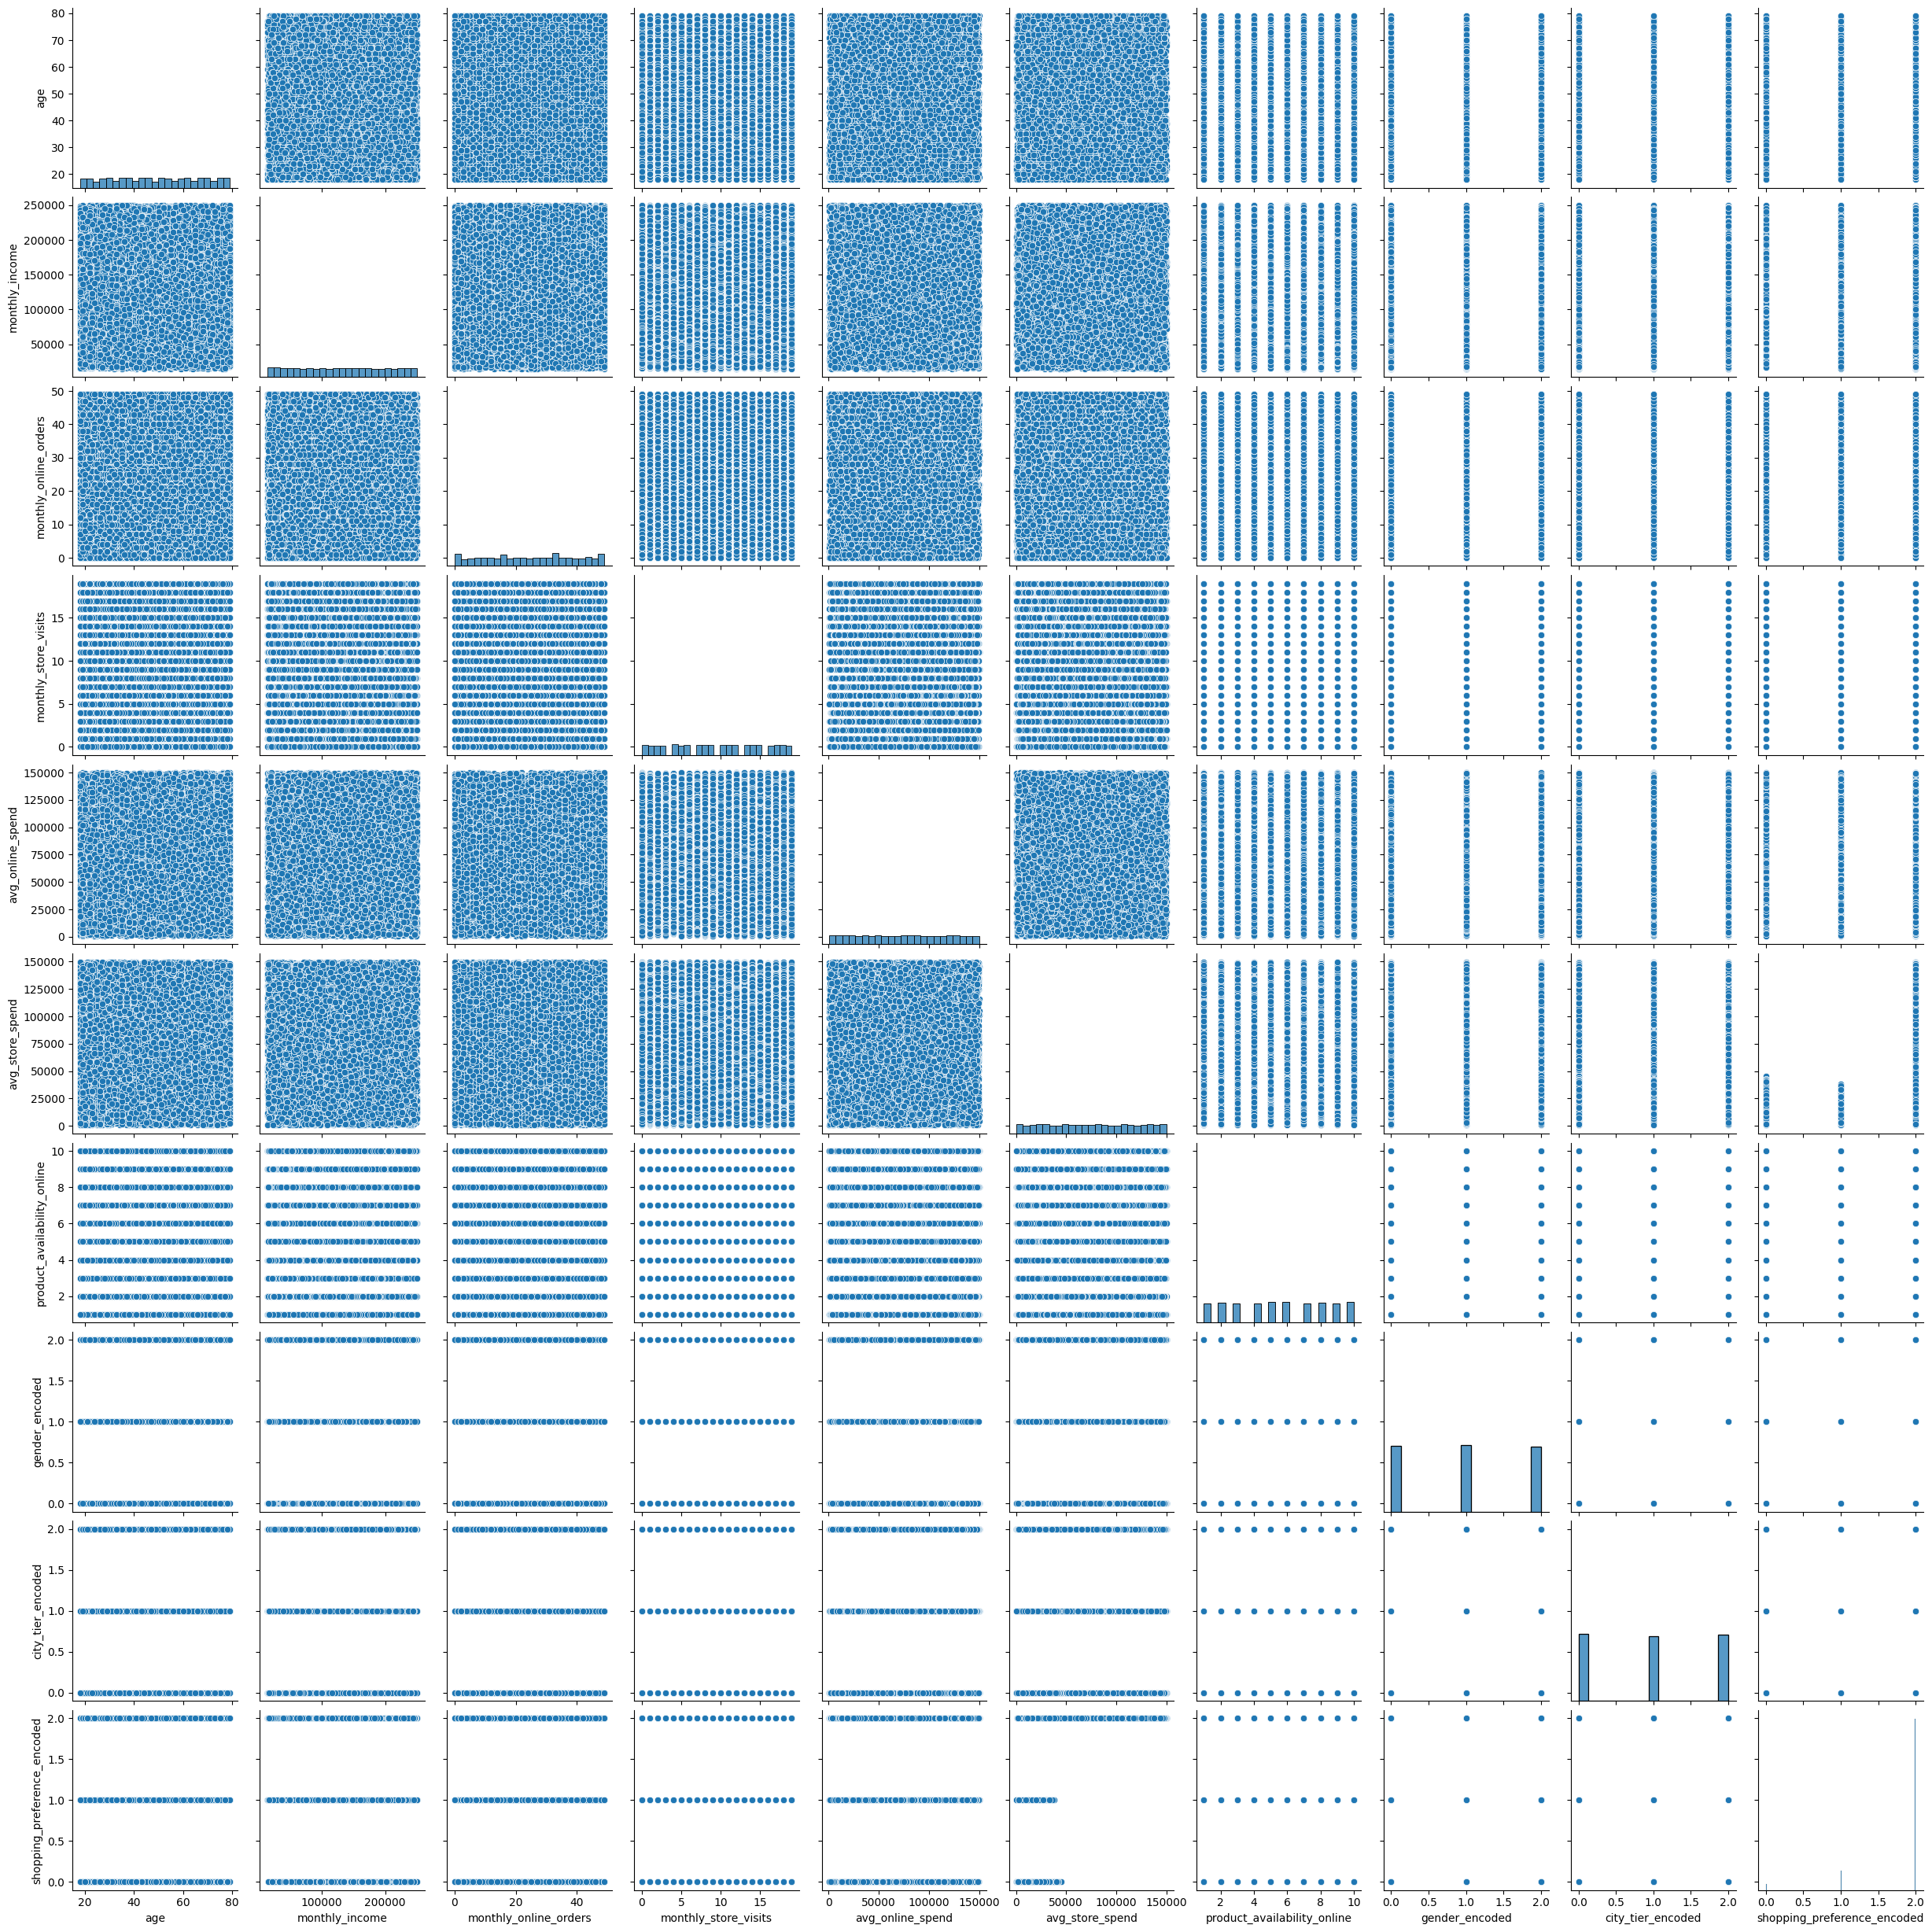

In [4]:
sns.pairplot(df)

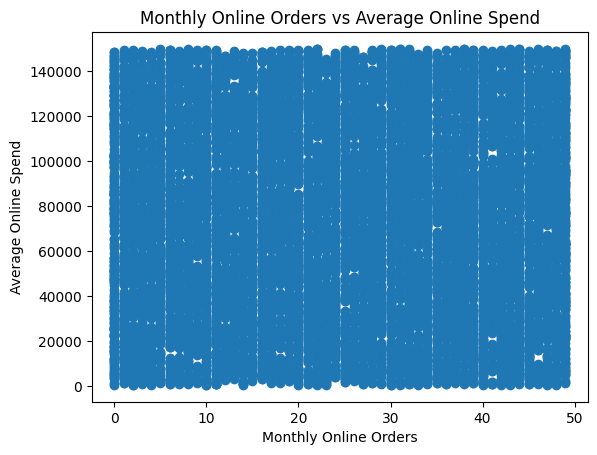

In [7]:
plt.scatter(df['monthly_online_orders'], df['avg_online_spend'])
plt.title('Monthly Online Orders vs Average Online Spend')
plt.xlabel('Monthly Online Orders')
plt.ylabel('Average Online Spend')
plt.show()

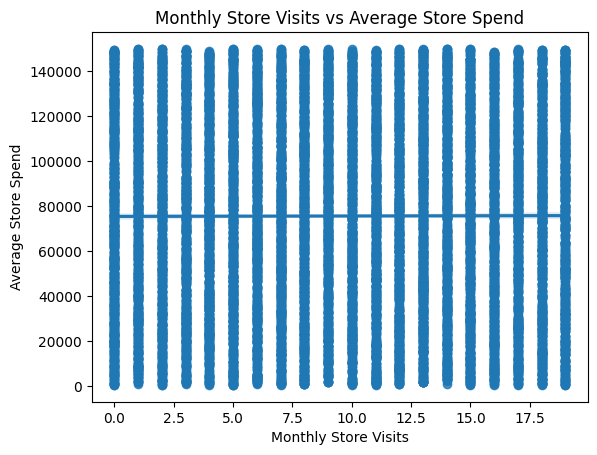

In [8]:
sns.regplot(x='monthly_store_visits', y='avg_store_spend', data=df)
plt.title('Monthly Store Visits vs Average Store Spend')
plt.xlabel('Monthly Store Visits')
plt.ylabel('Average Store Spend')
plt.show()

## Implementing Linear Regression

In [10]:
# Independent and dependent features
X = df[['age', 'monthly_income', 'monthly_online_orders', 'product_availability_online', 'gender_encoded', 'shopping_preference_encoded', 'city_tier_encoded', 'product_availability_online']]
y = df['avg_online_spend']

In [11]:
X.head()

,age,monthly_income,monthly_online_orders,product_availability_online,gender_encoded,shopping_preference_encoded,city_tier_encoded,product_availability_online
0,56,221111,16,7,2,2,2,7
1,69,96029,14,4,1,0,2,4
2,46,19055,2,10,0,2,2,10
3,32,53170,20,2,0,2,0,2
4,60,244016,18,5,1,2,2,5


In [12]:
y.head()

0     28551
1    124056
2     81939
3     35901
4    131971
Name: avg_online_spend, dtype: int64

In [13]:
##Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
X_train

,age,monthly_income,monthly_online_orders,product_availability_online,gender_encoded,shopping_preference_encoded,city_tier_encoded,product_availability_online
8410,76,197214,21,1,2,2,2,1
5064,74,49364,31,3,2,1,1,3
3844,37,156916,4,10,0,2,2,10
10072,22,32167,44,3,2,2,1,3
4392,74,172591,43,6,2,2,2,6
...,...,...,...,...,...,...,...,...
11284,75,73073,39,2,1,2,0,2
5191,61,211480,49,9,0,0,0,9
5390,62,74030,48,1,1,2,1,1
860,21,246075,10,2,1,2,2,2


In [15]:
X_test

,age,monthly_income,monthly_online_orders,product_availability_online,gender_encoded,shopping_preference_encoded,city_tier_encoded,product_availability_online
8015,78,109088,41,7,2,1,0,7
10821,79,106954,9,4,0,2,1,4
2755,29,249417,46,5,0,2,2,5
1935,41,227153,26,10,2,2,0,10
11254,26,240440,22,7,0,2,1,7
...,...,...,...,...,...,...,...,...
5885,41,145251,38,2,0,2,2,2
8446,39,106544,25,9,2,2,2,9
7254,43,196709,14,8,1,2,1,8
7305,61,133671,10,8,2,1,0,8


In [16]:
#Standaedizing the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
X_train

,age,monthly_income,monthly_online_orders,product_availability_online,gender_encoded,shopping_preference_encoded,city_tier_encoded,product_availability_online
8410,76,197214,21,1,2,2,2,1
5064,74,49364,31,3,2,1,1,3
3844,37,156916,4,10,0,2,2,10
10072,22,32167,44,3,2,2,1,3
4392,74,172591,43,6,2,2,2,6
...,...,...,...,...,...,...,...,...
11284,75,73073,39,2,1,2,0,2
5191,61,211480,49,9,0,0,0,9
5390,62,74030,48,1,1,2,1,1
860,21,246075,10,2,1,2,2,2


In [18]:
X_test

,age,monthly_income,monthly_online_orders,product_availability_online,gender_encoded,shopping_preference_encoded,city_tier_encoded,product_availability_online
8015,78,109088,41,7,2,1,0,7
10821,79,106954,9,4,0,2,1,4
2755,29,249417,46,5,0,2,2,5
1935,41,227153,26,10,2,2,0,10
11254,26,240440,22,7,0,2,1,7
...,...,...,...,...,...,...,...,...
5885,41,145251,38,2,0,2,2,2
8446,39,106544,25,9,2,2,2,9
7254,43,196709,14,8,1,2,1,8
7305,61,133671,10,8,2,1,0,8


## Model Training 

In [19]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()  
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
print("Coefficients:", model.coef_)

Coefficients: [ 993.25508331  497.34444695  132.0725464   112.72243352  208.39416161
 -150.21369946   75.09934253  112.72243352]


In [21]:
print("Intercept:", model.intercept_)

Intercept: 74649.3633761001


In [22]:
model.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

In [23]:
##Predicting on the test set
y_pred = model.predict(X_test_scaled)

In [24]:
y_pred

array([76820.72878628, 75576.78231765, 74345.66485162, ...,
       74846.38837066, 75850.2329173 , 75573.10742748], shape=(2358,))

Text(0.5, 1.0, 'Actual vs Predicted Average Online Spend')

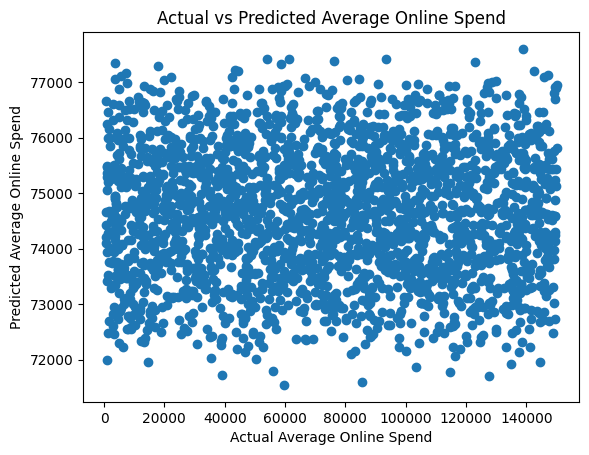

In [25]:
#Scatter plot of actual vs predicted values
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Average Online Spend')   
plt.ylabel('Predicted Average Online Spend')
plt.title('Actual vs Predicted Average Online Spend')

In [27]:
## Residuals 
residuals = y_test - y_pred

In [28]:
residuals

8015    -58359.728786
10821    16284.217682
2755    -68596.664852
1935    -35346.650486
11254    42619.491229
             ...     
5885    -52524.078699
8446    -25959.433744
7254    -62008.388371
7305     39513.767083
8908     -3124.107427
Name: avg_online_spend, Length: 2358, dtype: float64

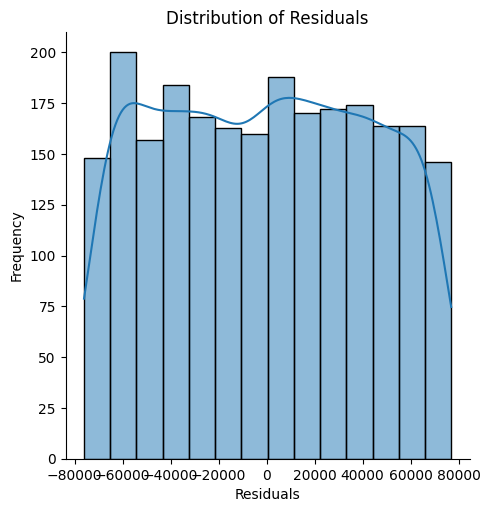

In [30]:
#Plotting residuals
sns.displot(residuals, kde=True)    
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

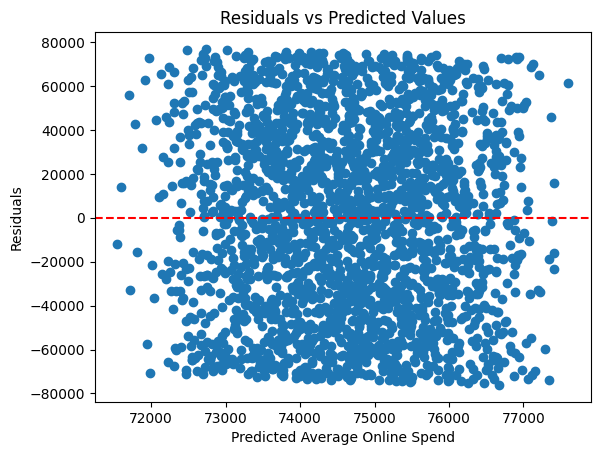

In [31]:
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Average Online Spend')
plt.ylabel('Residuals')
plt.show()

In [34]:
# Calculating error metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score   
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)         
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

Mean Absolute Error (MAE): 37589.76740730833
Mean Squared Error (MSE): 1888521402.021149
Root Mean Squared Error (RMSE): 43457.121418947536
R-squared (R2): -0.0007950806000285304
